In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Path", encoding='latin1')

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ï»¿customerID     7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df = df.rename(columns={'ï»¿customerID': 'customerID'})

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df['TotalCharges'].isnull().sum()

11

In [9]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
#check duplicate customers
df.duplicated().sum()

0

In [14]:
#Averge Monthly spend
df['Avgmonthlyspend']=np.where(df['tenure']==0,df['MonthlyCharges'],df['TotalCharges']/df['tenure'])

In [15]:
df['long_term_customer']=np.where(df['tenure']>=24,1,0)

In [16]:
median_bill=df['MonthlyCharges'].median()
df['high_monthly_bill']=np.where(df['MonthlyCharges']>median_bill,1,0)

In [17]:
df['estimated_lifetime_value']= df['MonthlyCharges']* df['tenure']

In [18]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [20]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

In [21]:
X = df.drop(columns=["Churn"])

y = df["Churn"]

In [22]:
y=y.map({"Yes":1,"No":0})

In [23]:
categorical_columns= X.select_dtypes(include='object').columns

In [24]:
encoder=LabelEncoder()
for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

In [26]:
X_train.isnull().sum()

customerID                  0
gender                      0
SeniorCitizen               0
Partner                     0
Dependents                  0
tenure                      0
PhoneService                0
MultipleLines               0
InternetService             0
OnlineSecurity              0
OnlineBackup                0
DeviceProtection            0
TechSupport                 0
StreamingTV                 0
StreamingMovies             0
Contract                    0
PaperlessBilling            0
PaymentMethod               0
MonthlyCharges              0
TotalCharges                0
Avgmonthlyspend             0
long_term_customer          0
high_monthly_bill           0
estimated_lifetime_value    0
TotalServices               0
dtype: int64

In [27]:
X_train.isnull().sum().sum()

0

In [28]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit( X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred_log = log_model.predict(X_test)

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision :", precision_score(y_test, y_pred_log))
print("Recall :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC :", roc_auc_score(y_test,log_model.predict_proba(X_test)[:,1]))

Accuracy : 0.7977288857345636
Precision : 0.6403785488958991
Recall : 0.5427807486631016
F1 Score : 0.5875542691751086
ROC AUC : 0.8405616264951302


In [31]:
cm = confusion_matrix(y_test,y_pred_log)
print(cm)

[[921 114]
 [171 203]]


In [32]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)
y_pred_tree = tree_model.predict(X_test)

In [33]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)
forest_model.fit(X_train,y_train)
y_pred_forest = forest_model.predict(X_test)

In [34]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

results = []
for name, model in models.items():
    predictions = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probability)
    })
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.797729   0.640379  0.542781  0.587554  0.840562
1        Decision Tree  0.718240   0.470284  0.486631  0.478318  0.644282
2        Random Forest  0.787083   0.627586  0.486631  0.548193  0.830563


In [35]:
import pandas as pd
import numpy as np

import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [36]:
X = df.drop(columns=["Churn"])

y = df["Churn"]

In [37]:
y = y.map({
    "Yes":1,
    "No":0
})

In [38]:
categorical_columns = X.select_dtypes(include="object").columns

encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
explainer = shap.TreeExplainer(model)

In [42]:
shap_values = explainer.shap_values(X_test)

In [43]:
print(shap_values)

[[[ 5.23809958e-04 -5.23809958e-04]
  [-2.29166022e-04  2.29166022e-04]
  [ 1.46874959e-03 -1.46874959e-03]
  ...
  [-3.90642521e-03  3.90642521e-03]
  [ 1.46736854e-02 -1.46736854e-02]
  [ 1.39056971e-02 -1.39056971e-02]]

 [[-1.11898325e-02  1.11898325e-02]
  [-8.84111138e-03  8.84111138e-03]
  [-2.15067207e-02  2.15067207e-02]
  ...
  [-1.60412659e-02  1.60412659e-02]
  [-2.50269132e-02  2.50269132e-02]
  [-2.45961674e-03  2.45961674e-03]]

 [[-1.76073827e-02  1.76073827e-02]
  [ 1.17644807e-03 -1.17644807e-03]
  [ 4.85141440e-03 -4.85141440e-03]
  ...
  [-3.01540704e-03  3.01540704e-03]
  [ 9.25923673e-03 -9.25923673e-03]
  [ 2.69257232e-03 -2.69257232e-03]]

 ...

 [[ 9.16787996e-04 -9.16787996e-04]
  [ 2.27205003e-03 -2.27205003e-03]
  [ 3.28979650e-03 -3.28979650e-03]
  ...
  [ 1.20968699e-02 -1.20968699e-02]
  [-6.86958179e-03  6.86958179e-03]
  [-2.17070993e-03  2.17070993e-03]]

 [[ 5.13018627e-03 -5.13018627e-03]
  [ 2.43555318e-03 -2.43555318e-03]
  [ 1.84509334e-03 -1.8450

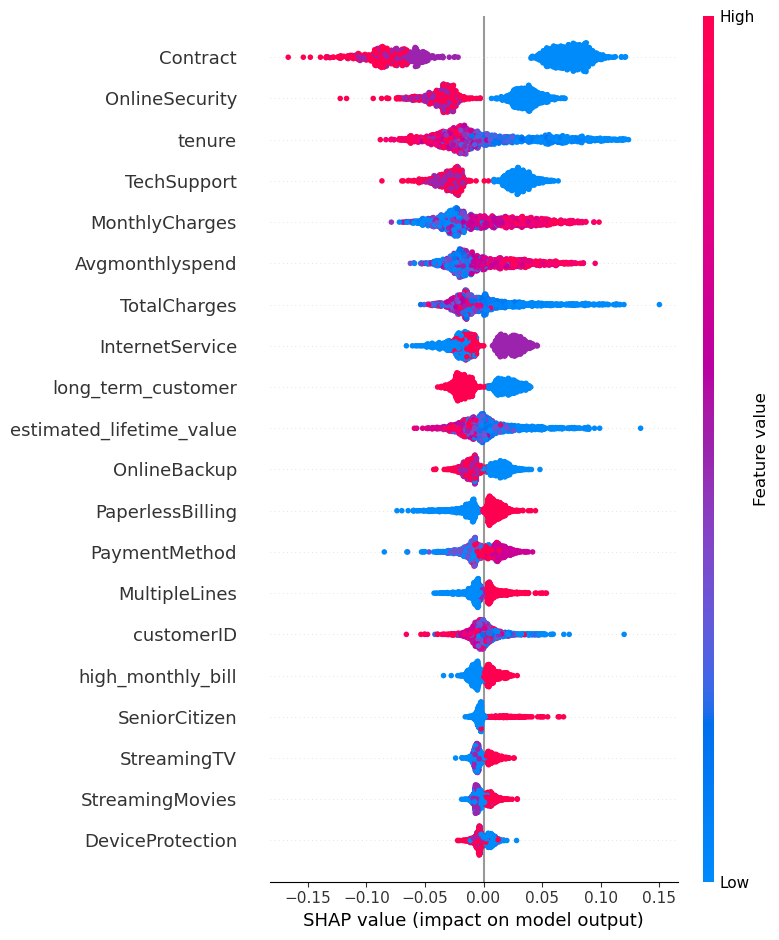

In [44]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test
)

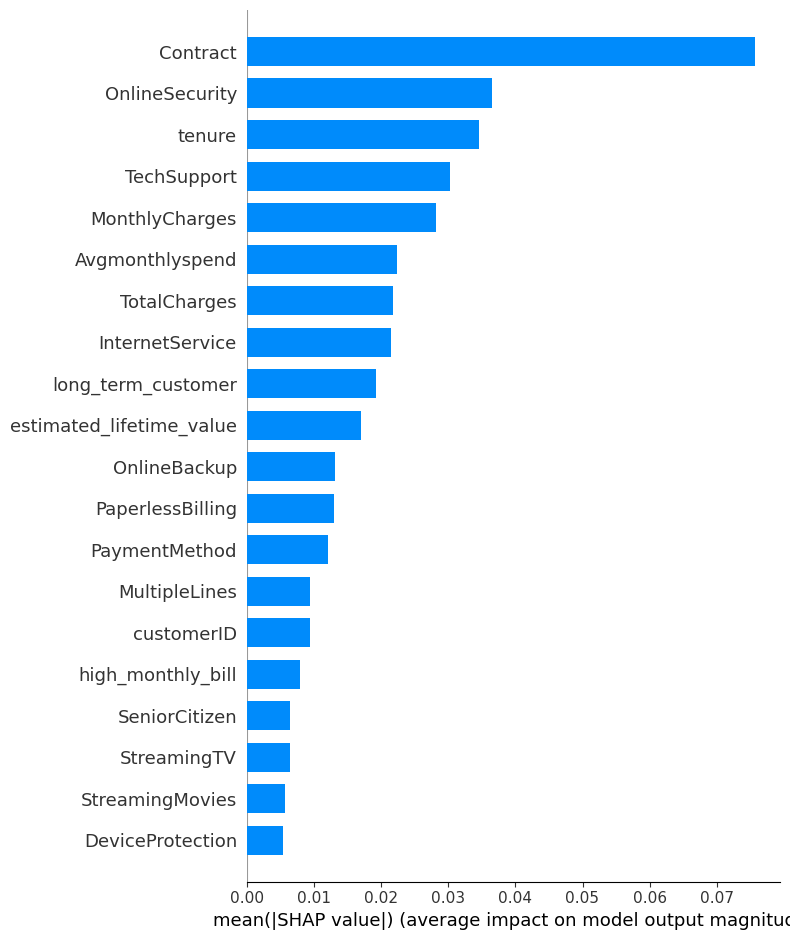

In [45]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    plot_type="bar"
)

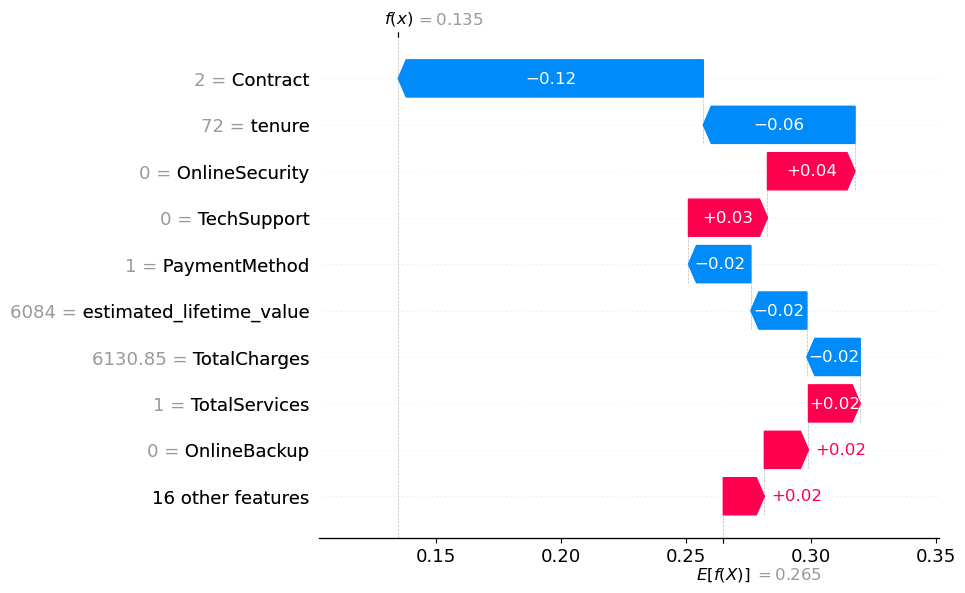

In [46]:
customer_number = 15
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:,:,1][customer_number],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[customer_number],
        feature_names=X_test.columns
    )
)

In [47]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[:,:,1][0],
    X_test.iloc[0]
)

In [48]:
customer = 15

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_values[:,:,1][customer]
})

feature_importance = feature_importance.sort_values(
    by="SHAP Value",
    ascending=False
)

print(feature_importance.head())

             Feature  SHAP Value
9     OnlineSecurity    0.035027
12       TechSupport    0.031623
24     TotalServices    0.020710
10      OnlineBackup    0.017654
11  DeviceProtection    0.011814
